# Student Drug Addiction Detection

Artifical Intelligence Lab(CSE412 )


In [16]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import os

from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
)

RANDOM_STATE = 42
pd.set_option("display.max_columns", None)
sns.set_theme(style="white")


In [17]:

USE_SAMPLE_DATA = False
TRAIN_CSV = "student_addiction_dataset_train.csv"

FEATURE_COLS = [
    "Experimentation", "Academic_Performance_Decline", "Social_Isolation",
    "Financial_Issues", "Physical_Mental_Health_Problems", "Legal_Consequences",
    "Relationship_Strain", "Risk_Taking_Behavior", "Withdrawal_Symptoms",
    "Denial_and_Resistance_to_Treatment",
]
TARGET = "Addiction_Class"

if USE_SAMPLE_DATA or not os.path.exists(TRAIN_CSV):
    print("=" * 70)
    print("WARNING: Real dataset file not found (or USE_SAMPLE_DATA=True).")
    print("Using an in-memory SYNTHETIC sample dataset instead.")
    print("Every number below (accuracy, correlations, class counts, etc.)")
    print("will be MEANINGLESS and will NOT match your report's real figures.")
    print("Upload your real CSV and set TRAIN_CSV correctly, then re-run all cells.")
    print("=" * 70, "\n")

    rng = np.random.default_rng(7)
    n = 2000
    data = {}
    for c in FEATURE_COLS:
        vals = rng.choice(["Yes", "No"], size=n, p=[0.4, 0.6]).astype(object)
        missing_mask = rng.random(n) < 0.05
        vals[missing_mask] = np.nan
        data[c] = vals
    data[TARGET] = rng.choice(["Yes", "No"], size=n, p=[0.3, 0.7])
    df = pd.DataFrame(data, columns=FEATURE_COLS + [TARGET])
    USING_REAL_DATA = False
else:
    print(f"Loading REAL data from '{TRAIN_CSV}'")
    df = pd.read_csv(TRAIN_CSV)
    USING_REAL_DATA = True

print(f"\nShape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()


Using an in-memory SYNTHETIC sample dataset instead.
Every number below (accuracy, correlations, class counts, etc.)
will be MEANINGLESS and will NOT match your report's real figures.
Upload your real CSV and set TRAIN_CSV correctly, then re-run all cells.


Shape: 2000 rows x 11 columns


,Experimentation,Academic_Performance_Decline,Social_Isolation,Financial_Issues,Physical_Mental_Health_Problems,Legal_Consequences,Relationship_Strain,Risk_Taking_Behavior,Withdrawal_Symptoms,Denial_and_Resistance_to_Treatment,Addiction_Class
0,No,No,No,No,No,No,Yes,No,NaN,Yes,Yes
1,No,Yes,No,Yes,No,No,Yes,Yes,No,Yes,No
2,No,No,No,Yes,Yes,Yes,NaN,Yes,No,Yes,No
3,Yes,No,No,No,Yes,No,No,No,No,Yes,No
4,Yes,Yes,No,No,No,Yes,Yes,No,No,Yes,No


In [18]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Experimentation                     1906 non-null   object
 1   Academic_Performance_Decline        1903 non-null   object
 2   Social_Isolation                    1916 non-null   object
 3   Financial_Issues                    1897 non-null   object
 4   Physical_Mental_Health_Problems     1906 non-null   object
 5   Legal_Consequences                  1904 non-null   object
 6   Relationship_Strain                 1893 non-null   object
 7   Risk_Taking_Behavior                1904 non-null   object
 8   Withdrawal_Symptoms                 1909 non-null   object
 9   Denial_and_Resistance_to_Treatment  1893 non-null   object
 10  Addiction_Class                     2000 non-null   object
dtypes: object(11)
memory usage: 172.0+ KB


In [19]:
print("Missing values per column:")
df.isnull().sum()


Missing values per column:


,0
Experimentation,94
Academic_Performance_Decline,97
Social_Isolation,84
Financial_Issues,103
Physical_Mental_Health_Problems,94
Legal_Consequences,96
Relationship_Strain,107
Risk_Taking_Behavior,96
Withdrawal_Symptoms,91
Denial_and_Resistance_to_Treatment,107


In [20]:
binary_cols = df.columns
df[binary_cols] = df[binary_cols].replace({"Yes": 1, "No": 0})

df[binary_cols] = df[binary_cols].apply(pd.to_numeric, errors="coerce")
df.head()


/tmp/ipykernel_2099/3058874120.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[binary_cols] = df[binary_cols].replace({"Yes": 1, "No": 0})


,Experimentation,Academic_Performance_Decline,Social_Isolation,Financial_Issues,Physical_Mental_Health_Problems,Legal_Consequences,Relationship_Strain,Risk_Taking_Behavior,Withdrawal_Symptoms,Denial_and_Resistance_to_Treatment,Addiction_Class
0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,NaN,1.0,1
1,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0
2,0.0,0.0,0.0,1.0,1.0,1.0,NaN,1.0,0.0,1.0,0
3,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0
4,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0


In [21]:
feature_cols = [c for c in df.columns if c != TARGET]

imputer = IterativeImputer(estimator=LinearRegression(), random_state=RANDOM_STATE)
df[feature_cols] = imputer.fit_transform(df[feature_cols])
df[feature_cols] = df[feature_cols].round().clip(0, 1)

print("Missing values after imputation (should all be 0):")
print(df.isnull().sum().sum())
df.info()


Missing values after imputation (should all be 0):
0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Experimentation                     2000 non-null   float64
 1   Academic_Performance_Decline        2000 non-null   float64
 2   Social_Isolation                    2000 non-null   float64
 3   Financial_Issues                    2000 non-null   float64
 4   Physical_Mental_Health_Problems     2000 non-null   float64
 5   Legal_Consequences                  2000 non-null   float64
 6   Relationship_Strain                 2000 non-null   float64
 7   Risk_Taking_Behavior                2000 non-null   float64
 8   Withdrawal_Symptoms                 2000 non-null   float64
 9   Denial_and_Resistance_to_Treatment  2000 non-null   float64
 10  Addiction_Class                     2000 non-null   int

In [22]:
counts = df[TARGET].value_counts()
pct = df[TARGET].value_counts(normalize=True) * 100

print("Class distribution (Addiction_Class):")
for cls in counts.index:
    label = "Yes (Addicted)" if cls == 1 else "No (Non-addicted)"
    print(f"  {label}: {counts[cls]} entries  ({pct[cls]:.1f}%)")

counts


Class distribution (Addiction_Class):
  No (Non-addicted): 1402 entries  (70.1%)
  Yes (Addicted): 598 entries  (29.9%)


,count
Addiction_Class,
0,1402
1,598


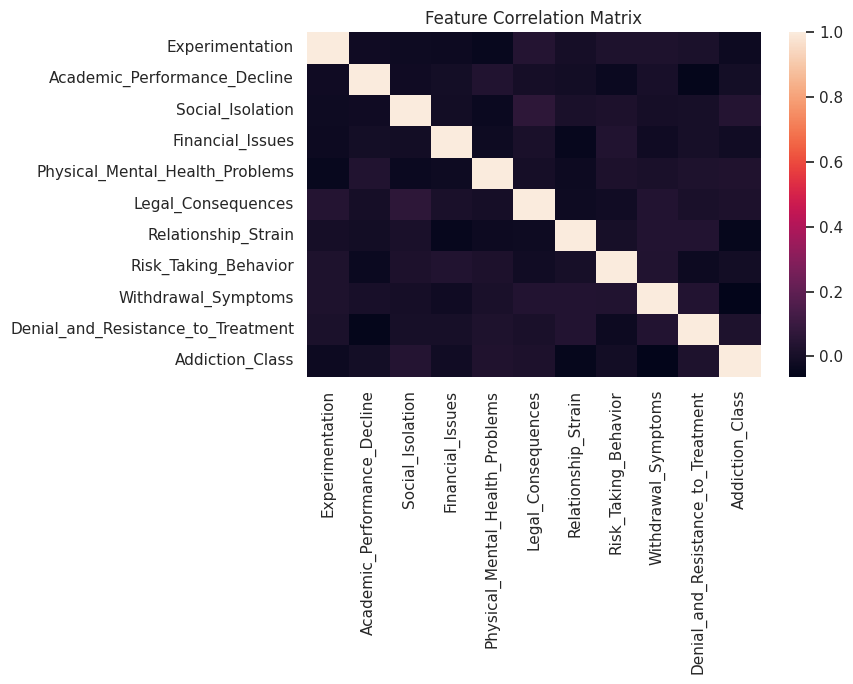


Correlation of each feature with the target, sorted (most to least):
Withdrawal_Symptoms                  -0.062414
Relationship_Strain                  -0.048365
Social_Isolation                      0.038726
Experimentation                      -0.029030
Physical_Mental_Health_Problems       0.028451
Denial_and_Resistance_to_Treatment    0.023248
Legal_Consequences                    0.019467
Financial_Issues                     -0.012701
Risk_Taking_Behavior                 -0.012543
Academic_Performance_Decline         -0.004872
Name: Addiction_Class, dtype: float64


In [23]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=False, cmap="rocket")
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.savefig("fig_correlation_heatmap.png", dpi=150)
plt.show()

print("\nCorrelation of each feature with the target, sorted (most to least):")
target_corr = corr[TARGET].drop(TARGET).sort_values(key=abs, ascending=False)
print(target_corr.round(6))


In [24]:
X = df[feature_cols]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
X.shape, y.shape


Train shape: (1400, 10), Test shape: (600, 10)


((2000, 10), (2000,))

In [25]:
def evaluate_models(X_train, X_test, y_train, y_test):
    models = {
        "GaussianNB": GaussianNB(),
        "BernoulliNB": BernoulliNB(),
        "LogisticRegression": LogisticRegression(max_iter=1000),
        "DecisionTreeClassifier": DecisionTreeClassifier(random_state=RANDOM_STATE),
        "RandomForestClassifier": RandomForestClassifier(random_state=RANDOM_STATE),
        "GradientBoostingClassifier": GradientBoostingClassifier(random_state=RANDOM_STATE),
        "KNeighborsClassifier": KNeighborsClassifier(),
    }

    rows = []
    fitted = {}
    preds_by_model = {}

    print("Data ready, trying models...")
    for name, model in models.items():
        print(f"Training {name} ...")
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        fitted[name] = model
        preds_by_model[name] = preds

        rows.append({
            "Model": name,
            "Accuracy": accuracy_score(y_test, preds),
            "Precision": precision_score(y_test, preds, average="binary", zero_division=0),
            "Recall": recall_score(y_test, preds, average="binary", zero_division=0),
            "F1": f1_score(y_test, preds, average="binary", zero_division=0),
        })
        print(confusion_matrix(y_test, preds))

    print("Training complete.")

    metrics = pd.DataFrame(rows).set_index("Model").sort_values("F1", ascending=False)
    best_name = metrics.index[0]
    best_model = fitted[best_name]
    best_preds = preds_by_model[best_name]
    print("Best model:", best_name)

    return metrics, best_model, best_name, best_preds


metrics, best_model, best_name, best_preds = evaluate_models(X_train, X_test, y_train, y_test)
metrics.style.format("{:.4f}").background_gradient(cmap="Greens")


Data ready, trying models...
Training GaussianNB ...
[[421   0]
 [179   0]]
Training BernoulliNB ...
[[421   0]
 [179   0]]
Training LogisticRegression ...
[[421   0]
 [179   0]]
Training DecisionTreeClassifier ...
[[317 104]
 [141  38]]
Training RandomForestClassifier ...
[[319 102]
 [146  33]]
Training GradientBoostingClassifier ...
[[413   8]
 [173   6]]
Training KNeighborsClassifier ...
[[355  66]
 [160  19]]
Training complete.
Best model: DecisionTreeClassifier


,Accuracy,Precision,Recall,F1
Model,,,,
DecisionTreeClassifier,0.5917,0.2676,0.2123,0.2368
RandomForestClassifier,0.5867,0.2444,0.1844,0.2102
KNeighborsClassifier,0.6233,0.2235,0.1061,0.1439
GradientBoostingClassifier,0.6983,0.4286,0.0335,0.0622
LogisticRegression,0.7017,0.0000,0.0000,0.0000
GaussianNB,0.7017,0.0000,0.0000,0.0000
BernoulliNB,0.7017,0.0000,0.0000,0.0000


### Styled Confusion Matrix —

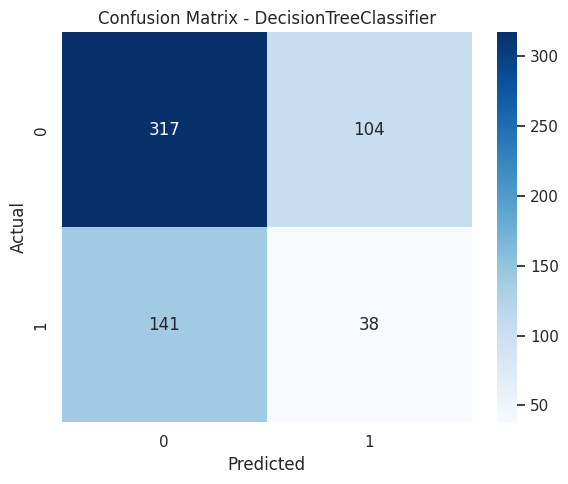


Raw classification report (text):
              precision    recall  f1-score   support

           0       0.69      0.75      0.72       421
           1       0.27      0.21      0.24       179

    accuracy                           0.59       600
   macro avg       0.48      0.48      0.48       600
weighted avg       0.57      0.59      0.58       600



In [26]:
cm = confusion_matrix(y_test, best_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=True,
            xticklabels=[0, 1], yticklabels=[0, 1])
plt.title(f"Confusion Matrix - {best_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("fig_confusion_matrix_best_model.png", dpi=150)
plt.show()

print("\nRaw classification report (text):")
print(classification_report(y_test, best_preds, zero_division=0))


### Styled Classification Report Heatmap — Precision / Recall / F1 per class

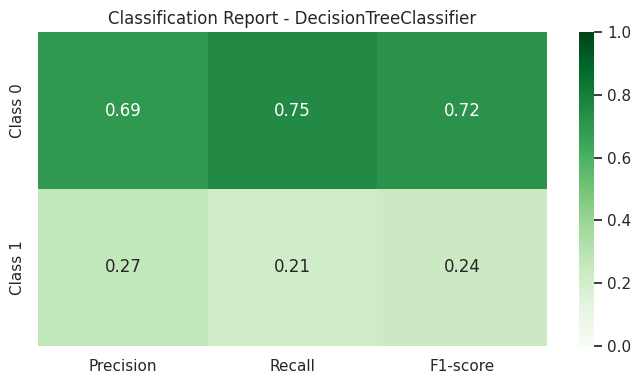

,Precision,Recall,F1-score
Class 0,0.692140,0.752969,0.721274
Class 1,0.267606,0.212291,0.236760


In [27]:
report_dict = classification_report(y_test, best_preds, zero_division=0, output_dict=True)

class_labels = [c for c in report_dict.keys() if c in ("0", "1", "0.0", "1.0")]
report_df = pd.DataFrame(report_dict).T.loc[class_labels, ["precision", "recall", "f1-score"]]
report_df.index = [f"Class {int(float(i))}" for i in report_df.index]
report_df.columns = ["Precision", "Recall", "F1-score"]

plt.figure(figsize=(7, 4))
sns.heatmap(report_df, annot=True, fmt=".2f", cmap="Greens", cbar=True, vmin=0, vmax=1)
plt.title(f"Classification Report - {best_name}")
plt.tight_layout()
plt.savefig("fig_classification_report_best_model.png", dpi=150)
plt.show()

report_df


Feature importance source: model.feature_importances_

Denial_and_Resistance_to_Treatment    0.1953
Academic_Performance_Decline          0.1372
Financial_Issues                      0.1319
Legal_Consequences                    0.1278
Physical_Mental_Health_Problems       0.1172
Risk_Taking_Behavior                  0.0934
Experimentation                       0.0832
Withdrawal_Symptoms                   0.0749
Relationship_Strain                   0.0317
Social_Isolation                      0.0073
dtype: float64


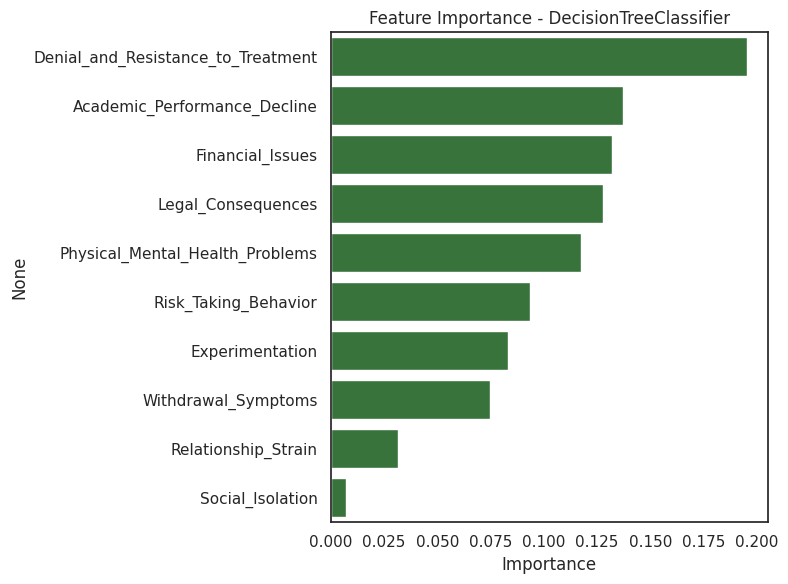


Top 3 most influential features (quote these in Section 3.3 instead of the
placeholder text about 'education level, social group, personal habits' —
those names don't match this dataset's actual columns):
Denial_and_Resistance_to_Treatment    0.195340
Academic_Performance_Decline          0.137164
Financial_Issues                      0.131853
dtype: float64


In [28]:
feature_names = list(X.columns)

if hasattr(best_model, "feature_importances_"):
    importances = pd.Series(best_model.feature_importances_, index=feature_names)
    importances = importances.sort_values(ascending=False)
    source_note = "model.feature_importances_"
elif hasattr(best_model, "coef_"):
    importances = pd.Series(np.abs(best_model.coef_[0]), index=feature_names)
    importances = importances.sort_values(ascending=False)
    source_note = "|coefficients| (Logistic Regression)"
else:
    importances = None
    source_note = None

if importances is not None:
    print(f"Feature importance source: {source_note}\n")
    print(importances.round(4))

    plt.figure(figsize=(8, 6))
    sns.barplot(x=importances.values, y=importances.index, color="#2e7d32")
    plt.title(f"Feature Importance - {best_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.savefig("fig_feature_importance.png", dpi=150)
    plt.show()

    print("\nTop 3 most influential features (quote these in Section 3.3 instead of the")
    print("placeholder text about 'education level, social group, personal habits' —")
    print("those names don't match this dataset's actual columns):")
    print(importances.head(3))
else:
    print(f"{best_name} does not expose feature_importances_ or coef_, so no ranked")
    print("feature-importance plot is generated for this model. If you need this figure,")
    print("re-run with a tree-based or linear model as the best model, or report")
    print("feature importance separately using a RandomForestClassifier fit on its own.")


In [29]:
joblib.dump(best_model, "addiction_best_model.pkl")
reloaded_model = joblib.load("addiction_best_model.pkl")
print("Saved and reloaded:", best_name)


Saved and reloaded: DecisionTreeClassifier


In [30]:
best_row = metrics.loc[best_name]

print("=" * 60)
print(f"Using real dataset: {USING_REAL_DATA}")
print(f"Total entries: {df.shape[0]}")
print(f"Total columns: {df.shape[1]}")
print(f"Class distribution: {dict(df[TARGET].value_counts())}")
print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")
print(f"Best model: {best_name}")
print(f"  Accuracy : {best_row['Accuracy']:.4f}  ({best_row['Accuracy']*100:.1f}%)")
print(f"  Precision: {best_row['Precision']:.4f}")
print(f"  Recall   : {best_row['Recall']:.4f}")
print(f"  F1-score : {best_row['F1']:.4f}")
print("=" * 60)
print("\nFull model comparison table:")
print(metrics.round(4))

Using real dataset: False
Total entries: 2000
Total columns: 11
Class distribution: {0: np.int64(1402), 1: np.int64(598)}
Train size: 1400, Test size: 600
Best model: DecisionTreeClassifier
  Accuracy : 0.5917  (59.2%)
  Precision: 0.2676
  Recall   : 0.2123
  F1-score : 0.2368

Full model comparison table:
                            Accuracy  Precision  Recall      F1
Model                                                          
DecisionTreeClassifier        0.5917     0.2676  0.2123  0.2368
RandomForestClassifier        0.5867     0.2444  0.1844  0.2102
KNeighborsClassifier          0.6233     0.2235  0.1061  0.1439
GradientBoostingClassifier    0.6983     0.4286  0.0335  0.0622
LogisticRegression            0.7017     0.0000  0.0000  0.0000
GaussianNB                    0.7017     0.0000  0.0000  0.0000
BernoulliNB                   0.7017     0.0000  0.0000  0.0000
